In [4]:
# Task 2: Short-Term Stock Price Prediction

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Fetch historical data for Apple (AAPL)
ticker = "AAPL"
df = yf.download(ticker, start="2021-01-01", end="2026-01-01")

# Clean multi-level column indexes if yfinance formats them uniquely
df.columns = df.columns.get_level_values(0) if isinstance(df.columns, pd.MultiIndex) else df.columns
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-01-04,125.740868,129.821783,123.166001,129.734338,143301900
2021-01-05,127.295464,128.004777,124.788613,125.235577,97664900
2021-01-06,123.010513,127.334347,122.796750,124.098761,155088000
2021-01-07,127.208046,127.897922,124.234808,124.720632,109578200
2021-01-08,128.305969,128.869526,126.537565,128.675185,105158200


In [6]:
# This creates a column for the target value (Next Day's Close Price)
df['Next_Close'] = df['Close'].shift(-1)

# Drop the very last row because it won't have a next day's closing price to match against
df = df.dropna()

# Define our Features (X) and Target (y)
features = ['Open', 'High', 'Low', 'Volume']
X = df[features]
y = df['Next_Close']

# Split data into Training set (80%) and Testing set (20%) sequentially (preserving time order)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)  # Changed 'test_split' to 'test_size'

In [7]:
# Initialize and train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on our test dataset
predictions = model.predict(X_test)

In [8]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

Mean Absolute Error (MAE): $3.09
R-squared Score (R2): 0.9708


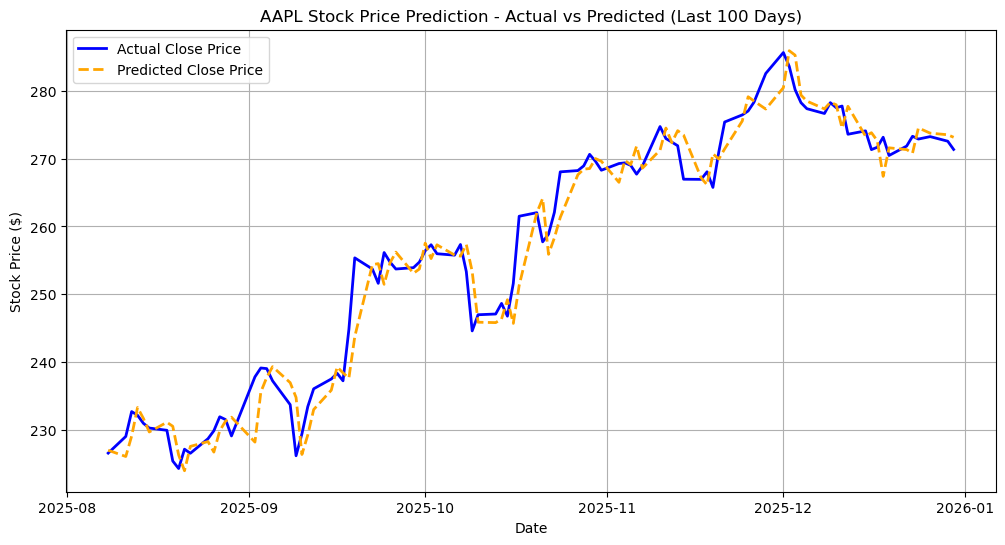

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index[-100:], y_test.values[-100:], label="Actual Close Price", color="blue", linewidth=2)
plt.plot(y_test.index[-100:], predictions[-100:], label="Predicted Close Price", color="orange", linestyle="--", linewidth=2)

plt.title(f"{ticker} Stock Price Prediction - Actual vs Predicted (Last 100 Days)")
plt.xlabel("Date")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.grid(True)
plt.show()